# Task 2
## Feature Engineering, Model Optimization & Performance Comparison

## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Load the Dataset

In [2]:
# Load the California Housing dataset
df = pd.read_csv("Data/housing.csv")

# Display the first five rows
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


## Step 3: Inspect the Dataset

In [3]:
df.shape

(20640, 10)

In [4]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Step 4: Handle Missing Values

In [7]:
# Fill missing values using the median
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

# Verify that no missing values remain
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## Step 5: Encode Categorical Features

In [8]:
# Convert categorical data into numerical data
df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,False,False,True,False


## Step 6: Separate Features and Target Variable

In [9]:
# Features
X = df.drop("median_house_value", axis=1)

# Target
y = df["median_house_value"]

## Step 7: Feature Scaling using StandardScaler

In [10]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

In [11]:
print(type(X_scaled))
print(X_scaled.shape)

<class 'numpy.ndarray'>
(20640, 12)


## Step 8: Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16512, 12)
X_test : (4128, 12)
y_train: (16512,)
y_test : (4128,)


## Step 9: Train Multiple Regression Models

In [14]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

In [15]:
results = {}

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate MSE
    mse = mean_squared_error(
        y_test,
        predictions
    )

    # Calculate RMSE
    rmse = np.sqrt(mse)

    # Calculate R²
    r2 = r2_score(
        y_test,
        predictions
    )

    # Store the results
    results[name] = {
        "RMSE": rmse,
        "R² Score": r2
    }

# Convert results to DataFrame
results_df = pd.DataFrame(results).T

results_df

,RMSE,R² Score
Linear Regression,70060.521845,0.625424
Ridge Regression,70057.419085,0.625457
Decision Tree,71510.900484,0.609755


In [16]:
best_model = results_df["R² Score"].idxmax()

print("Best Model:", best_model)

Best Model: Ridge Regression


## RMSE Comparison

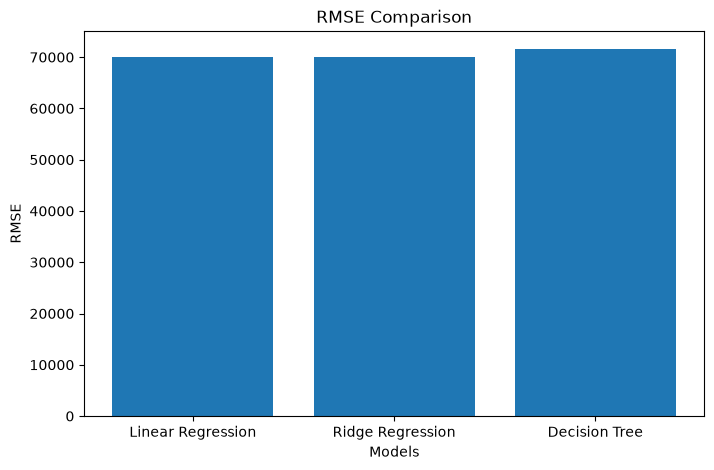

In [17]:
plt.figure(figsize=(8,5))

plt.bar(results_df.index, results_df["RMSE"])

plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

## R² Score Comparison

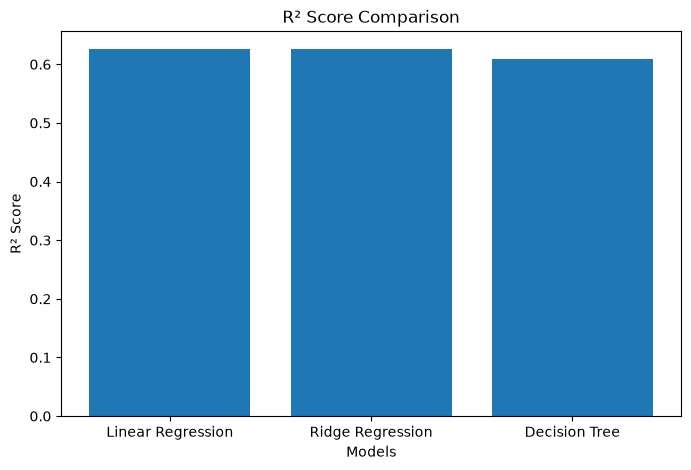

In [18]:
plt.figure(figsize=(8,5))

plt.bar(results_df.index, results_df["R² Score"])

plt.title("R² Score Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

## Model Comparison

The three regression models were evaluated using RMSE and R² Score.

### Observations

- Ridge Regression achieved the highest R² score.
- Linear Regression produced very similar performance.
- Decision Tree performed slightly worse on the test data.
- Therefore, Ridge Regression was selected as the best-performing model for this dataset.

### Conclusion

Feature scaling and regularization helped Ridge Regression achieve marginally better performance than Linear Regression. Decision Tree Regression, with the selected maximum depth, did not generalize as well on this dataset.

In [19]:
best_model = results_df["R² Score"].idxmax()

print("=" * 50)
print(f"🏆 Best Model: {best_model}")
print("=" * 50)

print(results_df)

🏆 Best Model: Ridge Regression
                           RMSE  R² Score
Linear Regression  70060.521845  0.625424
Ridge Regression   70057.419085  0.625457
Decision Tree      71510.900484  0.609755


## Step 10: Save the Best Model

In [20]:
import joblib

# Create and train the best model
best_model = Ridge(alpha=1.0)
best_model.fit(X_train, y_train)

# Save the trained model
joblib.dump(best_model, "ridge_house_price_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [21]:
import joblib

In [22]:
from sklearn.linear_model import Ridge

best_model = Ridge(alpha=1.0)
best_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [23]:
joblib.dump(best_model, "ridge_house_price_model.pkl")

['ridge_house_price_model.pkl']

## Save the Model and Preprocessing Objects

In [24]:
import joblib

In [41]:
import joblib

joblib.dump(best_model, "models/ridge_house_price_model.pkl")
print("✅ Ridge model saved successfully!")

✅ Ridge model saved successfully!
